In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [57]:
df = pd.read_csv("Datasets/beer.csv")
df.head()

,review_id,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv,aroma_score,appearance_score,taste_score,palate_score
0,1,Sausa Weizen,stcules,1.5,Unknown,AMERICAN IPA,<bound method Series.median of 0 NaN...,2.0,2.5,1.5,1.5
1,2,Red Moon,stcules,3.0,VECCHIO BIRRAIO,English Strong Ale,6.2,2.5,3.0,3.0,3.0
2,3,BLACK HORSE BLACK BEER,stcules,3.0,Unknown,AMERICAN IPA,<bound method Series.median of 0 NaN...,2.5,3.0,3.0,3.0
3,4,sausa pils,stcules,3.0,VECCHIO BIRRAIO,german pilsener,5.0,3.0,3.5,3.0,2.5
4,5,Cauldron Dipa,johnmichaelsen,4.0,Unknown,AMERICAN IPA,<bound method Series.median of 0 NaN...,4.5,4.0,4.5,4.0


In [58]:
df['beer_abv'] = pd.to_numeric(df['beer_abv'], errors='coerce')

In [59]:
df['beer_abv'].fillna(df['beer_abv'].median(), inplace=True)

In [60]:
df.head()

,review_id,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv,aroma_score,appearance_score,taste_score,palate_score
0,1,Sausa Weizen,stcules,1.5,Unknown,AMERICAN IPA,6.8,2.0,2.5,1.5,1.5
1,2,Red Moon,stcules,3.0,VECCHIO BIRRAIO,English Strong Ale,6.2,2.5,3.0,3.0,3.0
2,3,BLACK HORSE BLACK BEER,stcules,3.0,Unknown,AMERICAN IPA,6.8,2.5,3.0,3.0,3.0
3,4,sausa pils,stcules,3.0,VECCHIO BIRRAIO,german pilsener,5.0,3.0,3.5,3.0,2.5
4,5,Cauldron Dipa,johnmichaelsen,4.0,Unknown,AMERICAN IPA,6.8,4.5,4.0,4.5,4.0


In [61]:
df.shape

(251441, 11)

In [62]:
df.columns

Index(['review_id', 'beer_name', 'reviewer_username', 'overall_score',
       'brewery_name', 'beer_style', 'beer_abv', 'aroma_score',
       'appearance_score', 'taste_score', 'palate_score'],
      dtype='object')

## Objective 3: David vs Goliath – Does Brewery Size Affect Beer Quality?

This analysis investigates whether the size of a brewery affects the quality of the beers it produces. Large breweries typically have greater resources and production capacity, while smaller craft breweries may focus more on innovation and unique flavor profiles. By analyzing beer ratings across breweries of different sizes, we aim to determine whether large breweries consistently produce higher rated beers or whether smaller breweries can compete with them.

In [63]:
df1 = df[df['brewery_name'] != 'unknown'].copy()

In [64]:
cols = ["beer_name", "reviewer_username", "brewery_name", "beer_style"]

for col in cols:
    df[col] = df[col].astype(str).str.lower().str.strip().str.replace(r"\s+", " ", regex=True)

Brewery size is estimated using the number of reviews per brewery, assuming that larger breweries receive more consumer attention and therefore more reviews.

In [65]:
brewery_review_counts = df1.groupby('brewery_name')['overall_score'].count()

brewery_review_counts.head()


brewery_name
10 BARREL BREWING CO.     3
10 BARREL BREWING CO.     3
10 Barrel Brewing Co.     2
10 Barrel Brewing Co.     9
10 barrel brewing co.     2
Name: overall_score, dtype: int64

In [66]:
df1['brewery_review_count'] = df1['brewery_name'].map(brewery_review_counts)

df1.head()

,review_id,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv,aroma_score,appearance_score,taste_score,palate_score,brewery_review_count
0,1,Sausa Weizen,stcules,1.5,Unknown,AMERICAN IPA,6.8,2.0,2.5,1.5,1.5,130052
1,2,Red Moon,stcules,3.0,VECCHIO BIRRAIO,English Strong Ale,6.2,2.5,3.0,3.0,3.0,2
2,3,BLACK HORSE BLACK BEER,stcules,3.0,Unknown,AMERICAN IPA,6.8,2.5,3.0,3.0,3.0,130052
3,4,sausa pils,stcules,3.0,VECCHIO BIRRAIO,german pilsener,5.0,3.0,3.5,3.0,2.5,2
4,5,Cauldron Dipa,johnmichaelsen,4.0,Unknown,AMERICAN IPA,6.8,4.5,4.0,4.5,4.0,130052


In [67]:
def classify_brewery(size):
    if size > 5000:
        return "Large"
    elif size < 1000:
        return "Small"
    else:
        return "Medium"

df1['brewery_size'] = df1['brewery_review_count'].apply(classify_brewery)

df1['brewery_size'].value_counts()

brewery_size
Large     130052
Small      96976
Medium     24413
Name: count, dtype: int64

In [68]:
df1.groupby('brewery_size')['overall_score'].mean()

brewery_size
Large     3.856089
Medium    4.042906
Small     3.838907
Name: overall_score, dtype: float64

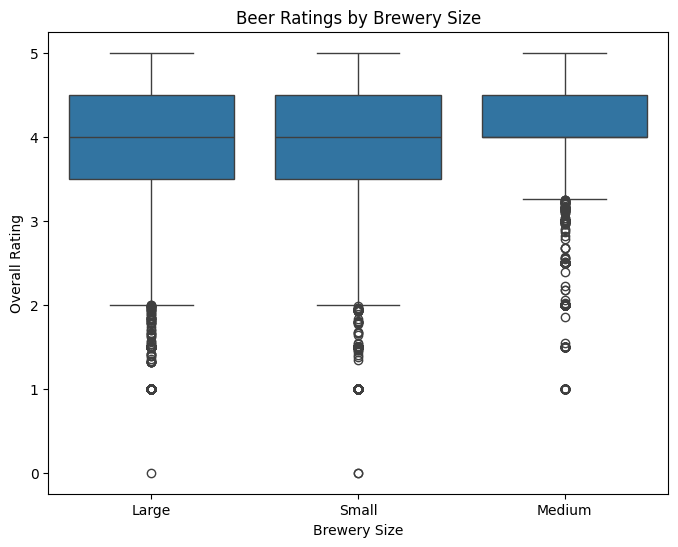

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(x='brewery_size', y='overall_score', data=df1)

plt.title("Beer Ratings by Brewery Size")
plt.xlabel("Brewery Size")
plt.ylabel("Overall Rating")

plt.show()

In [70]:
df1[['brewery_review_count','overall_score']].corr()

,brewery_review_count,overall_score
brewery_review_count,1.000000,-0.016702
overall_score,-0.016702,1.000000


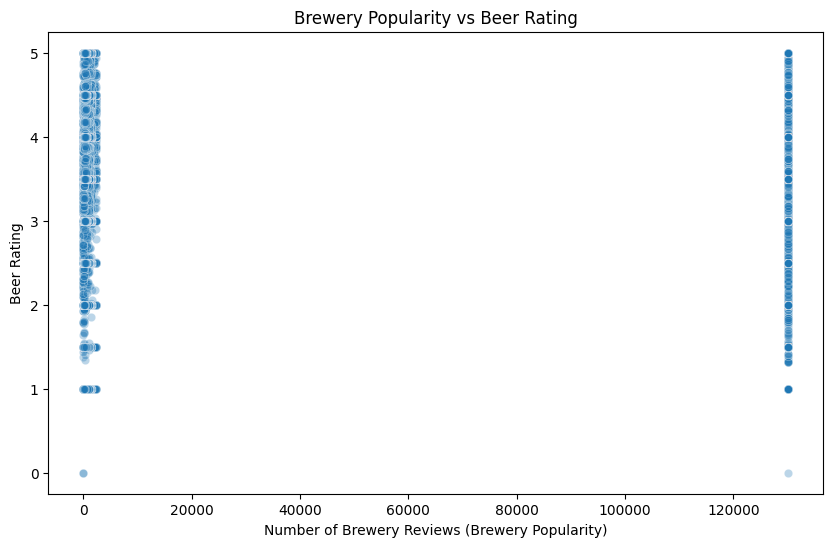

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='brewery_review_count',
    y='overall_score',
    data=df1,
    alpha=0.3
)

plt.title("Brewery Popularity vs Beer Rating")
plt.xlabel("Number of Brewery Reviews (Brewery Popularity)")
plt.ylabel("Beer Rating")

plt.show()

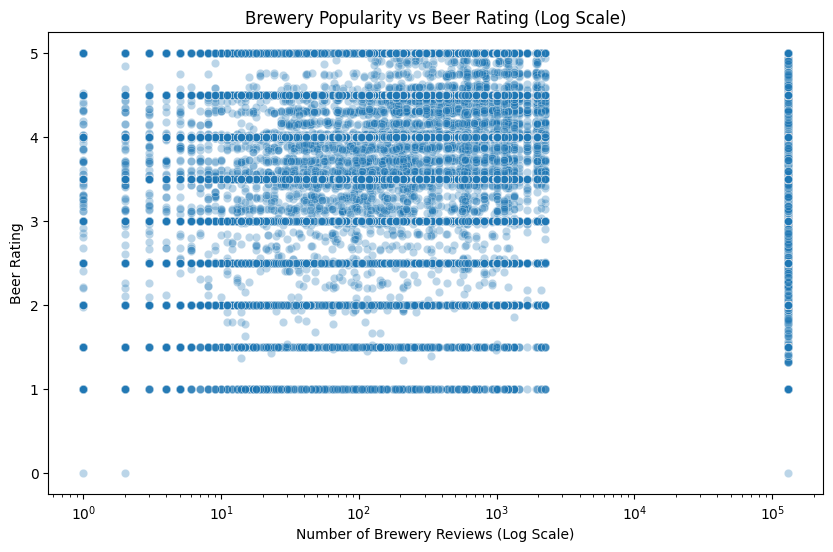

In [72]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='brewery_review_count',
    y='overall_score',
    data=df1,
    alpha=0.3
)

plt.xscale('log')

plt.title("Brewery Popularity vs Beer Rating (Log Scale)")
plt.xlabel("Number of Brewery Reviews (Log Scale)")
plt.ylabel("Beer Rating")

plt.show()

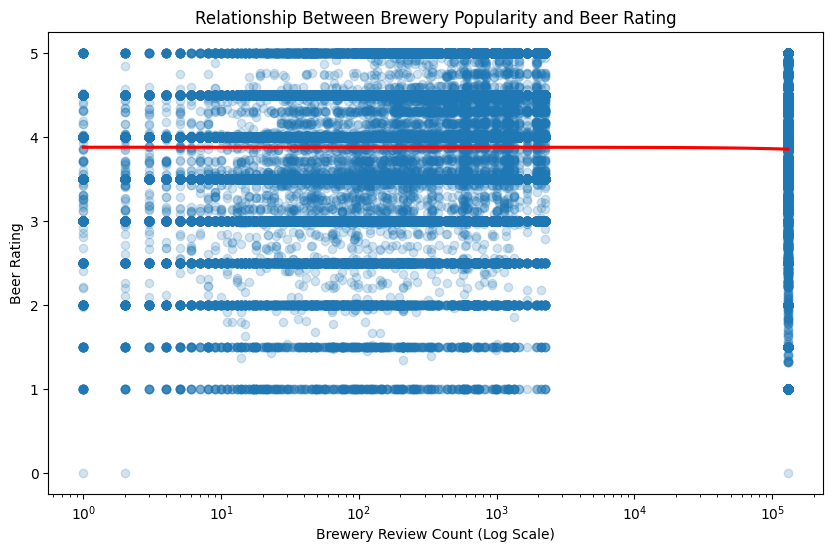

In [73]:
plt.figure(figsize=(10,6))

sns.regplot(
    x='brewery_review_count',
    y='overall_score',
    data=df1,
    scatter_kws={'alpha':0.2},
    line_kws={'color':'red'}
)

plt.xscale('log')

plt.title("Relationship Between Brewery Popularity and Beer Rating")
plt.xlabel("Brewery Review Count (Log Scale)")
plt.ylabel("Beer Rating")

plt.show()

In [74]:
df1.head()

,review_id,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv,aroma_score,appearance_score,taste_score,palate_score,brewery_review_count,brewery_size
0,1,Sausa Weizen,stcules,1.5,Unknown,AMERICAN IPA,6.8,2.0,2.5,1.5,1.5,130052,Large
1,2,Red Moon,stcules,3.0,VECCHIO BIRRAIO,English Strong Ale,6.2,2.5,3.0,3.0,3.0,2,Small
2,3,BLACK HORSE BLACK BEER,stcules,3.0,Unknown,AMERICAN IPA,6.8,2.5,3.0,3.0,3.0,130052,Large
3,4,sausa pils,stcules,3.0,VECCHIO BIRRAIO,german pilsener,5.0,3.0,3.5,3.0,2.5,2,Small
4,5,Cauldron Dipa,johnmichaelsen,4.0,Unknown,AMERICAN IPA,6.8,4.5,4.0,4.5,4.0,130052,Large
